## Step 1: Load Pre-split CSVs

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd

IMAGE_FOLDER = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/Thumbnails'
TRAIN_CSV    = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv'
VAL_CSV      = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv'
TEST_CSV     = '/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv'

for key, csv_path in [('train', TRAIN_CSV), ('validation', VAL_CSV), ('test', TEST_CSV)]:
    df = pd.read_csv(csv_path)
    df = df[['Image Path', 'label']].dropna(subset=['label']).reset_index(drop=True)
    df['label'] = df['label'].astype(int)
    out = f'/kaggle/working/{key}_img.csv'
    df.to_csv(out, index=False)
    print(f'{key} saved → {out}')
    print(df['label'].value_counts(), '\n')

train saved → /kaggle/working/train_img.csv
label
0    2886
1    2116
Name: count, dtype: int64 

validation saved → /kaggle/working/validation_img.csv
label
0    412
1    303
Name: count, dtype: int64 

test saved → /kaggle/working/test_img.csv
label
0    825
1    605
Name: count, dtype: int64 



## Step 2: Image Dataset & DataLoader

In [2]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, csv_path, image_folder, transform=None):
        self.df = pd.read_csv(csv_path)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_folder, os.path.basename(row['Image Path']))
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(int(row['label']), dtype=torch.long)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageDataset('/kaggle/working/train_img.csv',      IMAGE_FOLDER, train_transform)
val_dataset   = ImageDataset('/kaggle/working/validation_img.csv', IMAGE_FOLDER, val_transform)
test_dataset  = ImageDataset('/kaggle/working/test_img.csv',       IMAGE_FOLDER, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 5002 | Val: 715 | Test: 1430


## Step 3: Swin Transformer Image-Only Model

In [3]:
import torch.nn as nn
from torchvision import models

class SwinImageModel(nn.Module):
    """
    Swin Transformer (Swin-B) pretrained on ImageNet
    with a custom classification head for clickbait detection.
    """
    def __init__(self, num_classes=2, dropout=0.3):
        super(SwinImageModel, self).__init__()
        # Swin-B backbone
        self.backbone = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1)
        in_features = self.backbone.head.in_features
        # Replace classification head
        self.backbone.head = nn.Identity()
        # Custom classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, images):
        features = self.backbone(images)   # (B, 1024)
        logits   = self.classifier(features)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SwinImageModel(num_classes=2, dropout=0.3).to(device)
print(model)
print(f'\nDevice: {device}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /root/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth


100%|██████████| 335M/335M [00:01<00:00, 205MB/s] 


SwinImageModel(
  (backbone): SwinTransformer(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (1): Permute()
        (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (1): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (proj): Linear(in_features=128, out_features=128, bias=True)
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_features=128, out_features=512, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=512, out_features=128, bias=True)
            (4): Dropout

## Step 4: Training Setup

In [4]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS       = 15
LR           = 2e-4
WEIGHT_DECAY = 1e-4

# Class-weighted loss to handle imbalance
train_df = pd.read_csv('/kaggle/working/train_img.csv')
counts   = train_df['label'].value_counts().sort_index().values
weights  = torch.tensor(1.0 / counts, dtype=torch.float).to(device)
weights  = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'Class weights: {weights.cpu().numpy()}')

Class weights: [0.42303076 0.5769692 ]


## Step 5: Train & Evaluate

In [5]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1

best_val_f1     = 0.0
best_model_path = '/kaggle/working/swin_image_best.pth'

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    train_loss /= len(train_loader)
    val_loss, val_acc, val_f1 = evaluate(val_loader)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Acc: {val_acc:.4f} | '
          f'Val F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (F1={best_val_f1:.4f})')

print(f'\nTraining complete. Best Val F1: {best_val_f1:.4f}')

Epoch 01/15 | Train Loss: 0.6916 | Val Loss: 0.6653 | Val Acc: 0.6112 | Val F1: 0.6127
  ✓ Best model saved (F1=0.6127)
Epoch 02/15 | Train Loss: 0.6604 | Val Loss: 0.6648 | Val Acc: 0.6364 | Val F1: 0.6158
  ✓ Best model saved (F1=0.6158)
Epoch 03/15 | Train Loss: 0.6451 | Val Loss: 0.6930 | Val Acc: 0.5469 | Val F1: 0.5288
Epoch 04/15 | Train Loss: 0.5945 | Val Loss: 0.6608 | Val Acc: 0.6727 | Val F1: 0.6537
  ✓ Best model saved (F1=0.6537)
Epoch 05/15 | Train Loss: 0.5247 | Val Loss: 0.6792 | Val Acc: 0.6476 | Val F1: 0.6472
Epoch 06/15 | Train Loss: 0.4057 | Val Loss: 0.6906 | Val Acc: 0.6867 | Val F1: 0.6864
  ✓ Best model saved (F1=0.6864)
Epoch 07/15 | Train Loss: 0.2823 | Val Loss: 0.9369 | Val Acc: 0.6993 | Val F1: 0.6909
  ✓ Best model saved (F1=0.6909)
Epoch 08/15 | Train Loss: 0.2054 | Val Loss: 1.1752 | Val Acc: 0.6755 | Val F1: 0.6644
Epoch 09/15 | Train Loss: 0.1581 | Val Loss: 1.1115 | Val Acc: 0.6797 | Val F1: 0.6764
Epoch 10/15 | Train Loss: 0.0921 | Val Loss: 1.6250 

## Step 6: Test Evaluation & Metrics

=== Test Classification Report ===
               precision    recall  f1-score   support

Non-Clickbait       0.69      0.80      0.74       825
    Clickbait       0.66      0.51      0.57       605

     accuracy                           0.68      1430
    macro avg       0.67      0.66      0.66      1430
 weighted avg       0.68      0.68      0.67      1430

ROC-AUC: 0.7336


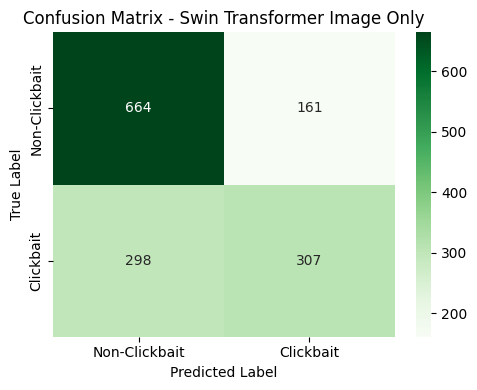

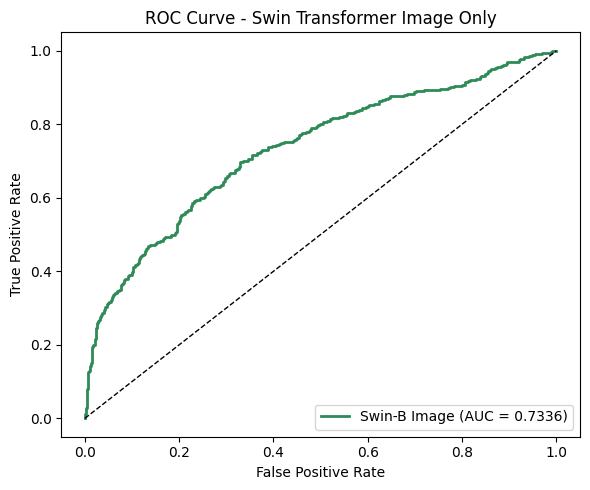

Plots saved.


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load best checkpoint
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print('=== Test Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=['Non-Clickbait', 'Clickbait']))

auc = roc_auc_score(all_labels, all_probs)
print(f'ROC-AUC: {auc:.4f}')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.title('Confusion Matrix - Swin Transformer Image Only')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_swin_image.png', dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Swin-B Image (AUC = {auc:.4f})', color='seagreen', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Swin Transformer Image Only')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_swin_image.png', dpi=150)
plt.show()
print('Plots saved.')